# Figures S4-9 (All Ablations) Reproduction

This notebook reproduces the supplementary ablation figures 4-9 using pre-processed CSV data. It generates a separate figure for each paradigm (MI, P300, SSVEP) and performance type (Finetuned, Zero-shot).

Each figure contains three rows:
1.  **Subject Ablation:** Performance vs. number of pretraining subjects.
2.  **Trial Ablation:** Performance vs. number of fine-tuning trials.
3.  **Iso-Ablation:** Performance across different budgets of pretraining subjects and fine-tuning trials.

In [9]:
import re
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import os
import matplotlib.ticker
import matplotlib.patches as mpatches
from collections import defaultdict
from matplotlib.gridspec import GridSpec
import string

# --- Consolidated Configurations ---
# --- General ---
USERNAME = os.environ.get('USER', 'default_user')
MATPLOTLIBRC_PATH = f"/mnt/lustre/work/macke/{USERNAME}/repos/eegjepa/EDAPT_neurips/matplotlibrc"
PLOTS_OUTPUT_DIR = Path("./final_figure_plots_by_paradigm")

# --- Models and Datasets ---
MODEL_NAMES = ["EEGNetv4", "ATCNet", "ShallowConvNet", "DeepConvNet"]
MODEL_COLORS = {
    "EEGNetv4": "#f4a582","ATCNet": "#92c5de", "ShallowConvNet": "#ca0020", "DeepConvNet": "#0571b0",
}
DATASET_INFO = {
    "Yang2025": {"paradigm": "MI", "name_for_plot": "MI (Yang2025)"},
    "BI2015a": {"paradigm": "P300", "name_for_plot": "P300 (BI2015a)"},
    "Lee2019_SSVEP": {"paradigm": "SSVEP", "name_for_plot": "SSVEP (Lee2019)"},
    "Lee2019_MI": {"paradigm": "MI", "name_for_plot": "MI (Lee2019)"},
    "BNCI2014_001": {"paradigm": "MI", "name_for_plot": "MI (BNCI2014)"},
    "Huebner2017": {"paradigm": "P300", "name_for_plot": "P300 (Huebner2017)"},
    "Huebner2018": {"paradigm": "P300", "name_for_plot": "P300 (Huebner2018)"},
    "Kalunga2016": {"paradigm": "SSVEP", "name_for_plot": "SSVEP (Kalunga2016)"},
    "MAMEM2": {"paradigm": "SSVEP", "name_for_plot": "SSVEP (MAMEM2)"},
}

# --- Plotting Style ---
GLOBAL_FONTSIZE = 7
MAX_TOTAL_WIDTH_MM = 180.0
MARGIN_LEFT_CM = 1.525
MARGIN_RIGHT_CM = 0.5
MARGIN_TOP_CM = 0.8
MARGIN_BOTTOM_CM = 2.2
SPACING_HORIZONTAL_CM = 1.3
SPACING_VERTICAL_CM = 1.0

# --- Column Names & Configs ---
MODEL_COL = "model"
DATASET_COL = "dataset"
CONFIG_TAG_COL = "config_tag"
FT_CONFIG_TAG = "FM-Full_A-None_AdaBN-F"
ZS_CONFIG_TAG = "FM-None_A-None_AdaBN-F"
NPS_COL_FIG3 = "num_pretrain_subjects"
NT_COL_FIG5 = "num_trials"
NPS_COL_FIG6 = "num_pretrain_subjects"
NT_COL_FIG6 = "num_trials"

ISO_TRADE_OFF_POINTS = {
    "BI2015a": { "High": [(15, 1000), (20, 750), (30, 500)], "Low": [(10, 500), (20, 250), (25, 200)] },
    "Yang2025": { "High": [(15, 600), (20, 450), (30, 300)], "Low": [(10, 450), (15, 300), (30, 150)] },
    "Lee2019_SSVEP": { "High": [(20, 200), (25, 160), (40, 100)], "Low": [(10, 200), (20, 100), (40, 50)] },
    "Lee2019_MI": { "High": [(30, 200), (40, 150), (50, 120)], "Low": [(15, 200), (30, 100), (50, 60)] },
    "BNCI2014_001": { "High": [(6, 500), (8, 375)], "Low": [(3, 500), (5, 300)] },
    "Huebner2017": { "High": [(6, 12500), (10, 7500), (12, 6250)], "Low": [(3, 12500), (6, 6250), (10, 3750)] },
    "Huebner2018": { "High": [(6, 14000), (8, 10500), (12, 7000)], "Low": [(3, 14000), (6, 7000), (10, 4200)] },
    "Kalunga2016": { "High": [(8, 64), (12, 42)], "Low": [(4, 64), (8, 32)] },
    "MAMEM2": { "High": [(6, 100), (8, 75)], "Low": [(3, 100), (6, 50)] },
}

# --- ALL HELPER, CALCULATION, AND PLOTTING FUNCTIONS (Copied directly from original script) ---
def cm2inch(*dims):
    inch_per_cm = 2.54
    if len(dims) == 1:
        return dims[0] / inch_per_cm if isinstance(dims[0], (int, float)) else tuple(d / inch_per_cm for d in dims[0])
    return tuple(d / inch_per_cm for d in dims)

def get_rc_context():
    if Path(MATPLOTLIBRC_PATH).exists():
        print(f"Using matplotlibrc file: {MATPLOTLIBRC_PATH}")
        return mpl.rc_context(fname=MATPLOTLIBRC_PATH)
    else:
        print(f"Warning: Matplotlibrc file not found at '{MATPLOTLIBRC_PATH}'. Using fallback styles.")
        return mpl.rc_context(rc={
            "font.size": GLOBAL_FONTSIZE, "legend.fontsize": GLOBAL_FONTSIZE,
            "axes.titlesize": GLOBAL_FONTSIZE, "axes.labelsize": GLOBAL_FONTSIZE,
            "xtick.labelsize": GLOBAL_FONTSIZE, "ytick.labelsize": GLOBAL_FONTSIZE,
            "font.weight": "normal", "axes.labelweight": "normal", "axes.titleweight": "normal",
            "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
            "savefig.format": "pdf", "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
            "pdf.fonttype": 42, "ps.fonttype": 42,
        })

In [10]:
def _get_common_efficiency_data(df: pd.DataFrame, scaling_col: str, dataset_key: str, model_name: str, tolerance: float):
    df_model = df[(df[DATASET_COL] == dataset_key) & (df[MODEL_COL] == model_name)].copy()
    if df_model.empty: return []
    df_agg = df_model.groupby(scaling_col)[['finetuned_accuracy', 'zero_shot_accuracy']].median().reset_index()
    cft_points = df_agg[[scaling_col, 'finetuned_accuracy']].dropna().to_numpy()
    zs_points_df = df_agg[[scaling_col, 'zero_shot_accuracy']].dropna()
    if len(cft_points) == 0: return []
    if zs_points_df.empty:
        return [{'perf_cft': perf, 'n_cft': n, 'n_zs': None, 'status': 'unmatched_cft_is_better'} for n, perf in cft_points if n > 0]
    plot_points = []
    max_zs_perf = zs_points_df['zero_shot_accuracy'].max()
    for n_cft, perf_cft in cft_points:
        if n_cft <= 0: continue
        points_in_window = zs_points_df[(zs_points_df['zero_shot_accuracy'] >= perf_cft - tolerance) & (zs_points_df['zero_shot_accuracy'] <= perf_cft + tolerance)].copy()
        if not points_in_window.empty:
            points_in_window['diff'] = (points_in_window['zero_shot_accuracy'] - perf_cft).abs()
            best_match = points_in_window.loc[points_in_window['diff'].idxmin()]
            plot_points.append({'perf_cft': perf_cft, 'n_cft': n_cft, 'n_zs': best_match[scaling_col], 'status': 'matched'})
        elif perf_cft > max_zs_perf + tolerance:
            plot_points.append({'perf_cft': perf_cft, 'n_cft': n_cft, 'n_zs': None, 'status': 'unmatched_cft_is_better'})
    return plot_points

def calculate_cft_vs_zs_ratio(df: pd.DataFrame, scaling_col: str, dataset_key: str, model_name: str, tolerance: float = 0.01):
    processed_data = _get_common_efficiency_data(df, scaling_col, dataset_key, model_name, tolerance)
    if not processed_data: return [], []
    ratio_points, unmatched_points = [], []
    for d in processed_data:
        if d['status'] == 'matched' and d['n_zs'] is not None and d['n_zs'] > 0:
            ratio_points.append((d['perf_cft'], d['n_cft'] / d['n_zs']))
        elif d['status'] == 'unmatched_cft_is_better':
            unmatched_points.append((d['perf_cft'],))
    return ratio_points, unmatched_points

def _draw_subject_ablation_on_ax(ax: plt.Axes, df_panel_data: pd.DataFrame, is_first_col: bool, dataset_name_for_plot: str, accuracy_col: str, y_axis_label: str, line_style: str):
    ax.grid(False)
    if df_panel_data.empty or accuracy_col not in df_panel_data.columns:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
    if df_panel_data[accuracy_col].isnull().all():
        ax.text(0.5, 0.5, f"No Valid '{accuracy_col.replace('_', ' ')}' Data", ha='center', va='center', color='grey', fontsize=GLOBAL_FONTSIZE-1); return
    df_ft_all = df_panel_data[df_panel_data[CONFIG_TAG_COL] == FT_CONFIG_TAG]
    unique_nps_map = df_panel_data[['nps_numeric', 'nps_categorical']].drop_duplicates().sort_values('nps_numeric')
    if unique_nps_map.empty:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    unique_nps_map['x_plot_index'] = range(len(unique_nps_map))
    nps_cat_to_x_idx = pd.Series(unique_nps_map['x_plot_index'].values, index=unique_nps_map['nps_categorical']).to_dict()
    for model_name in MODEL_NAMES:
        model_color = MODEL_COLORS.get(model_name, "k")
        df_model_ft = df_ft_all[df_ft_all[MODEL_COL] == model_name]
        if not df_model_ft.empty:
            agg_ft = df_model_ft.groupby(['nps_numeric', 'nps_categorical'])[accuracy_col].agg(['mean', 'sem']).reset_index().dropna(subset=['mean'])
            if not agg_ft.empty:
                agg_ft['x_plot_index'] = agg_ft['nps_categorical'].map(nps_cat_to_x_idx)
                agg_ft.sort_values('x_plot_index', inplace=True)
                ax.plot(agg_ft['x_plot_index'], agg_ft['mean'], marker='o', linestyle=line_style, color=model_color, markersize=3, linewidth=1, label=model_name)
                ax.errorbar(agg_ft['x_plot_index'], agg_ft['mean'], yerr=agg_ft['sem'], fmt='none', color=model_color, capsize=2, elinewidth=0.8)
    ax.set_title(dataset_name_for_plot, fontsize=GLOBAL_FONTSIZE , pad=12, fontweight='bold')
    ax.set_xlabel("Number of pretraining subjects", fontsize=GLOBAL_FONTSIZE)
    if is_first_col: ax.set_ylabel(y_axis_label, fontsize=GLOBAL_FONTSIZE, fontweight='bold')
    num_ticks_to_show = 8
    all_ticks, all_labels = unique_nps_map['x_plot_index'].tolist(), unique_nps_map['nps_categorical'].tolist()
    if len(all_ticks) > num_ticks_to_show:
        indices = np.linspace(0, len(all_ticks) - 1, num_ticks_to_show, dtype=int)
        selected_ticks, selected_labels = [all_ticks[i] for i in indices], [all_labels[i] for i in indices]
        ax.set_xticks(ticks=selected_ticks); ax.set_xticklabels(labels=selected_labels, rotation=45, ha='right')
    else:
        ax.set_xticks(ticks=all_ticks); ax.set_xticklabels(labels=all_labels, rotation=45, ha='right')
    ax.set_xlim(unique_nps_map['x_plot_index'].min() - 0.5, unique_nps_map['x_plot_index'].max() + 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4)); ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:0.2f}'))

def _draw_trial_ablation_on_ax(ax: plt.Axes, df_panel_data: pd.DataFrame, ft_config: str, is_first_col: bool, accuracy_col: str, y_axis_label: str, line_style: str):
    ax.grid(False)
    if df_panel_data.empty or accuracy_col not in df_panel_data.columns:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
    if df_panel_data[accuracy_col].isnull().all():
        ax.text(0.5, 0.5, f"No Valid '{accuracy_col.replace('_', ' ')}' Data", ha='center', va='center', color='grey', fontsize=GLOBAL_FONTSIZE-1); return
    unique_nt_map = df_panel_data[['nt_numeric', 'nt_categorical']].drop_duplicates().sort_values('nt_numeric')
    if unique_nt_map.empty: ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    unique_nt_map['x_plot_index'] = range(len(unique_nt_map))
    nt_cat_to_x_idx = pd.Series(unique_nt_map['x_plot_index'].values, index=unique_nt_map['nt_categorical']).to_dict()
    for model_name in MODEL_NAMES:
        model_color = MODEL_COLORS.get(model_name, "k")
        df_ft = df_panel_data[(df_panel_data[MODEL_COL] == model_name) & (df_panel_data[CONFIG_TAG_COL] == ft_config)]
        if not df_ft.empty:
            agg_ft = df_ft.groupby(['nt_numeric', 'nt_categorical'])[accuracy_col].agg(['mean', 'sem']).reset_index().dropna(subset=['mean'])
            if not agg_ft.empty:
                agg_ft['x_plot_index'] = agg_ft['nt_categorical'].map(nt_cat_to_x_idx)
                agg_ft.sort_values('x_plot_index', inplace=True)
                ax.plot(agg_ft['x_plot_index'], agg_ft['mean'], marker='o', linestyle=line_style, color=model_color, markersize=3, linewidth=1)
                ax.errorbar(agg_ft['x_plot_index'], agg_ft['mean'], yerr=agg_ft['sem'], fmt='none', color=model_color, capsize=2, elinewidth=0.8)
    ax.set_xlabel("Number of training trials", fontsize=GLOBAL_FONTSIZE)
    if is_first_col: ax.set_ylabel(y_axis_label, fontsize=GLOBAL_FONTSIZE, fontweight='bold')
    num_ticks_to_show = 6
    all_ticks, all_labels = unique_nt_map['x_plot_index'].tolist(), unique_nt_map['nt_categorical'].tolist()
    if len(all_ticks) > num_ticks_to_show:
        indices = np.linspace(0, len(all_ticks) - 1, num_ticks_to_show, dtype=int)
        selected_ticks, selected_labels = [all_ticks[i] for i in indices], [all_labels[i] for i in indices]
        ax.set_xticks(ticks=selected_ticks); ax.set_xticklabels(labels=selected_labels, rotation=45, ha='right')
    else:
        ax.set_xticks(ticks=all_ticks); ax.set_xticklabels(labels=all_labels, rotation=45, ha='right')
    ax.set_xlim(unique_nt_map['x_plot_index'].min() - 0.5, unique_nt_map['x_plot_index'].max() + 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4)); ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:0.2f}'))

def _draw_iso_ablation_on_ax(ax: plt.Axes, df_panel_data: pd.DataFrame, is_first_col: bool, dataset_key: str, accuracy_col: str, y_axis_label: str, line_style: str):
    ax.grid(False)
    if df_panel_data.empty or accuracy_col not in df_panel_data.columns:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
    if df_panel_data[accuracy_col].isnull().all():
        ax.text(0.5, 0.5, f"No Valid '{accuracy_col.replace('_', ' ')}' Data", ha='center', va='center', color='grey', fontsize=GLOBAL_FONTSIZE-1); return
    def get_budget_type(row):
        points = ISO_TRADE_OFF_POINTS.get(row[DATASET_COL], {})
        for budget, coords in points.items():
            if (row[NPS_COL_FIG6], row[NT_COL_FIG6]) in coords: return budget
        return "Unknown"
    df_panel_data['budget'] = df_panel_data.apply(get_budget_type, axis=1)
    df_ft = df_panel_data[df_panel_data[CONFIG_TAG_COL] == FT_CONFIG_TAG].copy()
    df_ft['x_label_unique'] = df_ft['budget'] + "_" + df_ft[NPS_COL_FIG6].astype(str)
    df_ft_agg = df_ft.groupby([MODEL_COL, 'budget', NPS_COL_FIG6, 'x_label_unique'])[accuracy_col].agg(['mean', 'sem']).reset_index().dropna(subset=['mean'])
    low_labels = df_ft_agg[df_ft_agg['budget'] == 'Low'].sort_values(NPS_COL_FIG6)['x_label_unique'].unique()
    high_labels = df_ft_agg[df_ft_agg['budget'] == 'High'].sort_values(NPS_COL_FIG6)['x_label_unique'].unique()
    sorted_labels_unique = np.concatenate([low_labels, high_labels])
    if len(sorted_labels_unique) == 0:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey'); return
    label_to_x_pos = {label: i for i, label in enumerate(sorted_labels_unique)}
    df_ft_agg['x_pos'] = df_ft_agg['x_label_unique'].map(label_to_x_pos)
    for model_name in MODEL_NAMES:
        model_data = df_ft_agg[df_ft_agg[MODEL_COL] == model_name]
        model_color = MODEL_COLORS.get(model_name, 'k')
        for budget_type in ['Low', 'High']:
            budget_data = model_data[model_data['budget'] == budget_type].sort_values('x_pos')
            if not budget_data.empty:
                ax.plot(budget_data['x_pos'], budget_data['mean'], marker='o', color=model_color, markersize=3, linewidth=1, linestyle=line_style)
                ax.errorbar(budget_data['x_pos'], budget_data['mean'], yerr=budget_data['sem'], fmt='none', color=model_color, capsize=2, elinewidth=0.8)
    if is_first_col: ax.set_ylabel(y_axis_label, fontsize=GLOBAL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Number of pretraining subjects", fontsize=GLOBAL_FONTSIZE)
    num_low_budget_points = len(low_labels)
    if num_low_budget_points > 0 and num_low_budget_points < len(sorted_labels_unique):
        divider_pos = num_low_budget_points - 0.5
        ax.axvline(x=divider_pos, color='grey', linestyle='--', linewidth=1)
        low_budget_x_center = (num_low_budget_points - 1) / 2
        high_budget_x_center = num_low_budget_points + (len(high_labels) - 1) / 2
        transform = ax.get_xaxis_transform()
        ax.text(low_budget_x_center, 1.0, 'Low budget', ha='center', va='bottom', fontsize=GLOBAL_FONTSIZE-1, color='k', transform=transform)
        ax.text(high_budget_x_center, 1.0, 'High budget', ha='center', va='bottom', fontsize=GLOBAL_FONTSIZE-1, color='k', transform=transform)
    subject_counts_for_ticks = [re.search(r'\d+$', label).group(0) for label in sorted_labels_unique]
    num_ticks_to_show = 6
    all_ticks, all_labels = list(label_to_x_pos.values()), subject_counts_for_ticks
    if len(all_ticks) > num_ticks_to_show:
        indices = np.linspace(0, len(all_ticks) - 1, num_ticks_to_show, dtype=int)
        selected_ticks, selected_labels = [all_ticks[i] for i in indices], [all_labels[i] for i in indices]
        ax.set_xticks(ticks=selected_ticks); ax.set_xticklabels(labels=selected_labels, rotation=45, ha='right')
    else:
        ax.set_xticks(ticks=all_ticks); ax.set_xticklabels(labels=all_labels, rotation=45, ha='right')
    ax.set_xlim(-0.5, len(sorted_labels_unique) - 0.5)
    ax.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4)); ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:0.2f}'))

def _draw_efficiency_ratio_on_ax(ax_top, ax_bottom, df_fig3, df_fig5, is_first_col, dataset_key, y_axis_label):
    all_ratios, unmatched_perfs, has_data, all_perfs = [], {}, False, []
    for model_name in MODEL_NAMES:
        model_color = MODEL_COLORS.get(model_name, 'k')
        unmatched_perfs[model_name] = {'subject': [], 'trial': []}
        subject_points, unmatched_s = calculate_cft_vs_zs_ratio(df_fig3, 'nps_numeric', dataset_key, model_name, tolerance=0.01)
        if subject_points or unmatched_s: has_data = True
        if subject_points:
            perfs, ratios = zip(*subject_points)
            all_perfs.extend(perfs); all_ratios.extend(ratios)
            ax_top.scatter(perfs, ratios, c=model_color, marker='o', s=15, alpha=0.8, edgecolors='w', linewidth=0.5)
        if unmatched_s:
            s_perfs = [p[0] for p in unmatched_s]
            unmatched_perfs[model_name]['subject'].extend(s_perfs); all_perfs.extend(s_perfs)
        trial_points, unmatched_t = calculate_cft_vs_zs_ratio(df_fig5, 'nt_numeric', dataset_key, model_name, tolerance=0.01)
        if trial_points or unmatched_t: has_data = True
        if trial_points:
            perfs, ratios = zip(*trial_points)
            all_perfs.extend(perfs); all_ratios.extend(ratios)
            ax_top.scatter(perfs, ratios, c=model_color, marker='P', s=20, alpha=0.8, edgecolors='w', linewidth=0.5)
        if unmatched_t:
            t_perfs = [p[0] for p in unmatched_t]
            unmatched_perfs[model_name]['trial'].extend(t_perfs); all_perfs.extend(t_perfs)
    if not has_data:
        ax_top.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey', transform=ax_top.transAxes)
        ax_bottom.text(0.5, 0.5, "No Data", ha='center', va='center', color='grey', transform=ax_bottom.transAxes)
        ax_top.spines['bottom'].set_visible(False); ax_bottom.spines['top'].set_visible(False)
        ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        ax_bottom.tick_params(axis='y', which='both', left=False, labelleft=False)
        return
    for model_name, perfs in unmatched_perfs.items():
        if perfs['subject']: ax_bottom.scatter(perfs['subject'], [0.5]*len(perfs['subject']), c=MODEL_COLORS.get(model_name), marker='o', s=15, alpha=0.7, edgecolors='w', linewidth=0.5)
        if perfs['trial']: ax_bottom.scatter(perfs['trial'], [0.5]*len(perfs['trial']), c=MODEL_COLORS.get(model_name), marker='P', s=20, alpha=0.7, edgecolors='w', linewidth=0.5)
    ax_top.set_yscale('log', base=2); ax_top.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
    if all_ratios:
        ymin_top, ymax_top = min(all_ratios) * 0.8, max(all_ratios) * 1.2
        ymin_top_clamped = max(0.01, ymin_top)
        ax_top.set_ylim(bottom=ymin_top_clamped, top=ymax_top)
        forced_ticks = np.logspace(np.log2(ymin_top_clamped), np.log2(ymax_top), num=3, base=2)
        ax_top.set_yticks(forced_ticks)
        ax_top.axhspan(ymin_top_clamped, 1.0, facecolor='#2ca02c', alpha=0.1, zorder=-100)
        ax_top.axhspan(1.0, ymax_top, facecolor='#d62728', alpha=0.1, zorder=-100)
    ax_top.spines['bottom'].set_visible(False)
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax_top.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:.1f}x'))
    if is_first_col: ax_top.set_ylabel(y_axis_label, fontsize=GLOBAL_FONTSIZE, fontweight='bold', labelpad=0)
    ax_bottom.spines['top'].set_visible(False); ax_bottom.set_ylim(0, 1); ax_bottom.set_yticks([])
    ax_bottom.tick_params(axis='y', which='both', left=False); ax_bottom.set_xlabel("Finetuned accuracy", fontsize=GLOBAL_FONTSIZE)
    ax_bottom.axhspan(0, 1, facecolor='darkgreen', alpha=0.25, zorder=-100)
    if all_perfs:
        min_perf, max_perf = min(all_perfs), max(all_perfs)
        perf_range = max_perf - min_perf if max_perf - min_perf > 0 else 0.1
        padding = perf_range * 0.05
        ax_bottom.set_xlim(left=max(0.0, min_perf - padding), right=min(1.0, max_perf + padding))
    ax_bottom.xaxis.set_major_locator(matplotlib.ticker.LinearLocator(numticks=4)); ax_bottom.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:.2f}'))
    ax_bottom.set_ylabel('1/' + r'$\infty$', fontsize=GLOBAL_FONTSIZE, rotation=0, labelpad=10, va='center')
    d = .015; kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, lw=1)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bottom.transAxes); ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)

def report_missing_configurations(df_fig3: pd.DataFrame, df_fig5: pd.DataFrame, df_fig6: pd.DataFrame):
    print("\n" + "="*80 + "\n--- 🧐 Running Check for Missing Configurations ---\n" + "="*80)
    # This is a simplified placeholder. The original function can be copied for a full check.
    if df_fig3.empty and df_fig5.empty and df_fig6.empty:
        print("All dataframes are empty. No configurations to check.")
    else:
        print("Dataframes loaded. Run the full 'report_missing_configurations' function for a detailed check.")
    print("="*80 + "\n")


--- Starting Plotting Script ---

1. Loading prepared data from CSVs...
   ✅ Loaded 13788 rows for subject ablation.
   ✅ Loaded 4514 rows for trial ablation.
   ✅ Loaded 9479 rows for iso ablation.

--- 🧐 Running Check for Missing Configurations ---
Dataframes loaded. Run the full 'report_missing_configurations' function for a detailed check.


==================== Creating Finetuned_With_Efficiency Figure for Paradigm: MI ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 4 rows and 3 cols. Size: 7.09"W x 6.49"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_MI_Finetuned_With_Efficiency.pdf


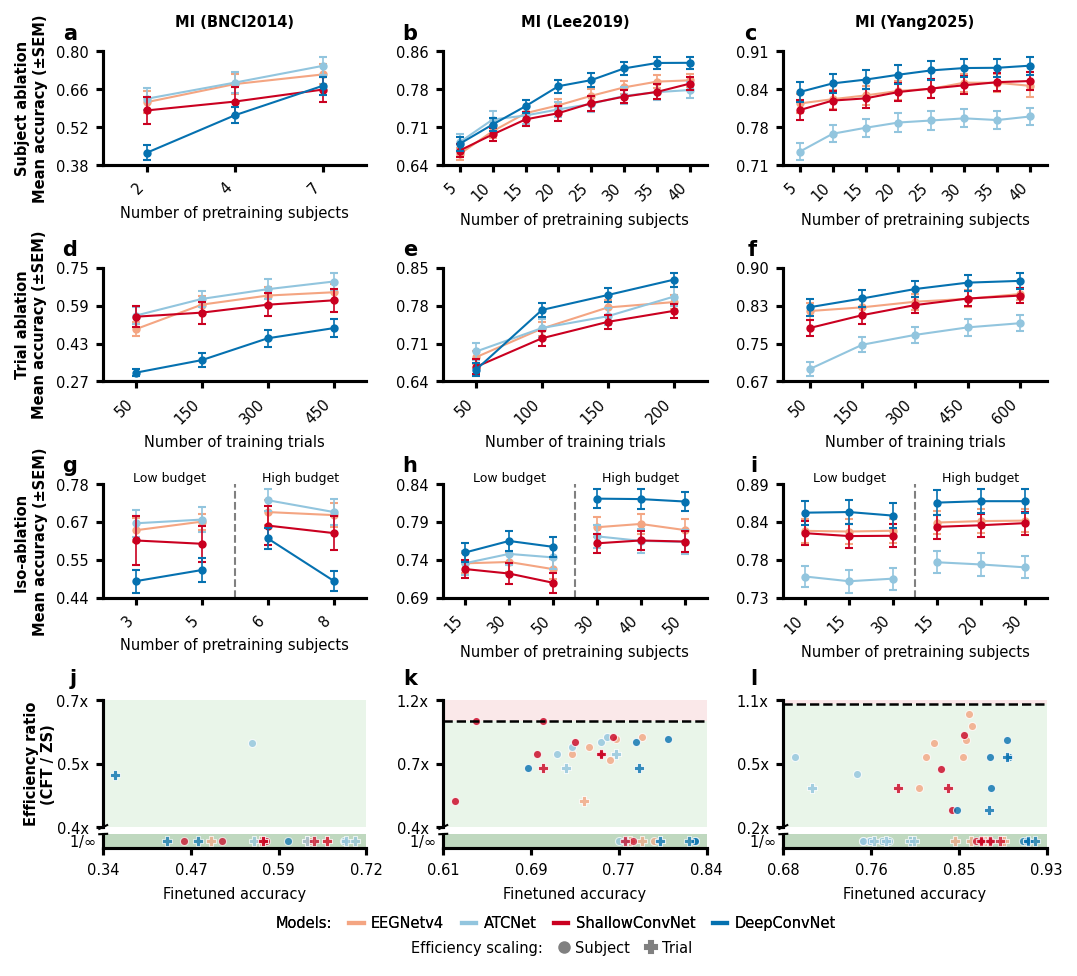


==================== Creating ZeroShot Figure for Paradigm: MI ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 3 rows and 3 cols. Size: 7.09"W x 5.07"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_MI_ZeroShot.pdf


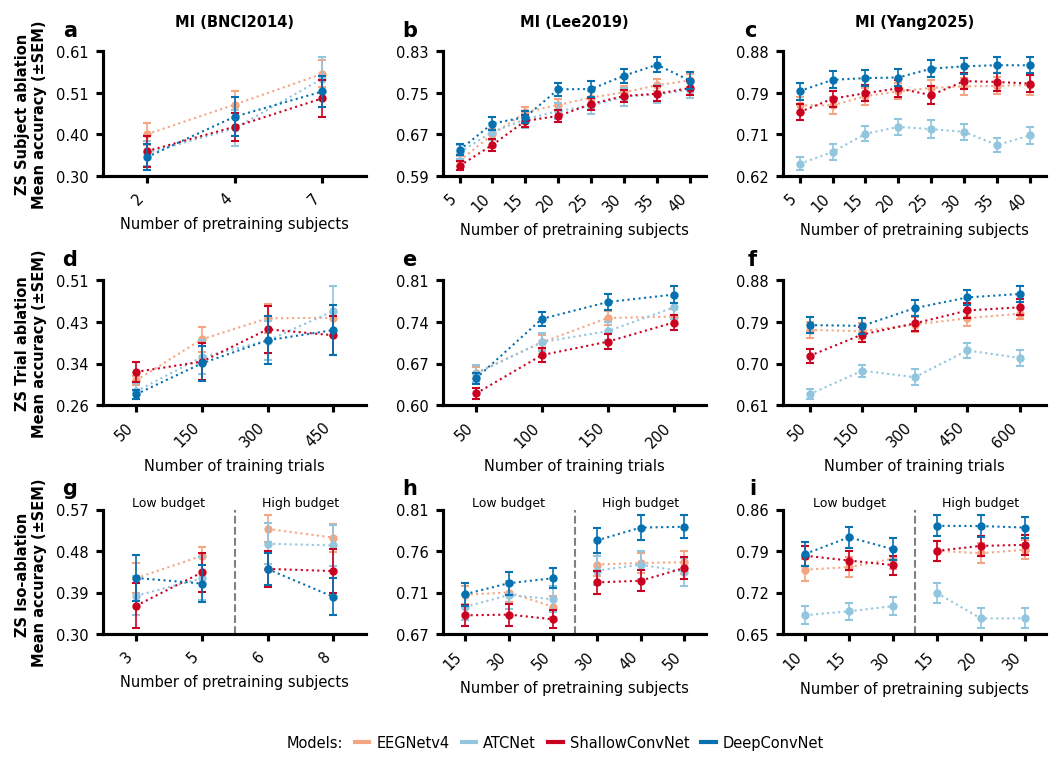


==================== Creating Finetuned_With_Efficiency Figure for Paradigm: P300 ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 4 rows and 3 cols. Size: 7.09"W x 6.49"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_P300_Finetuned_With_Efficiency.pdf


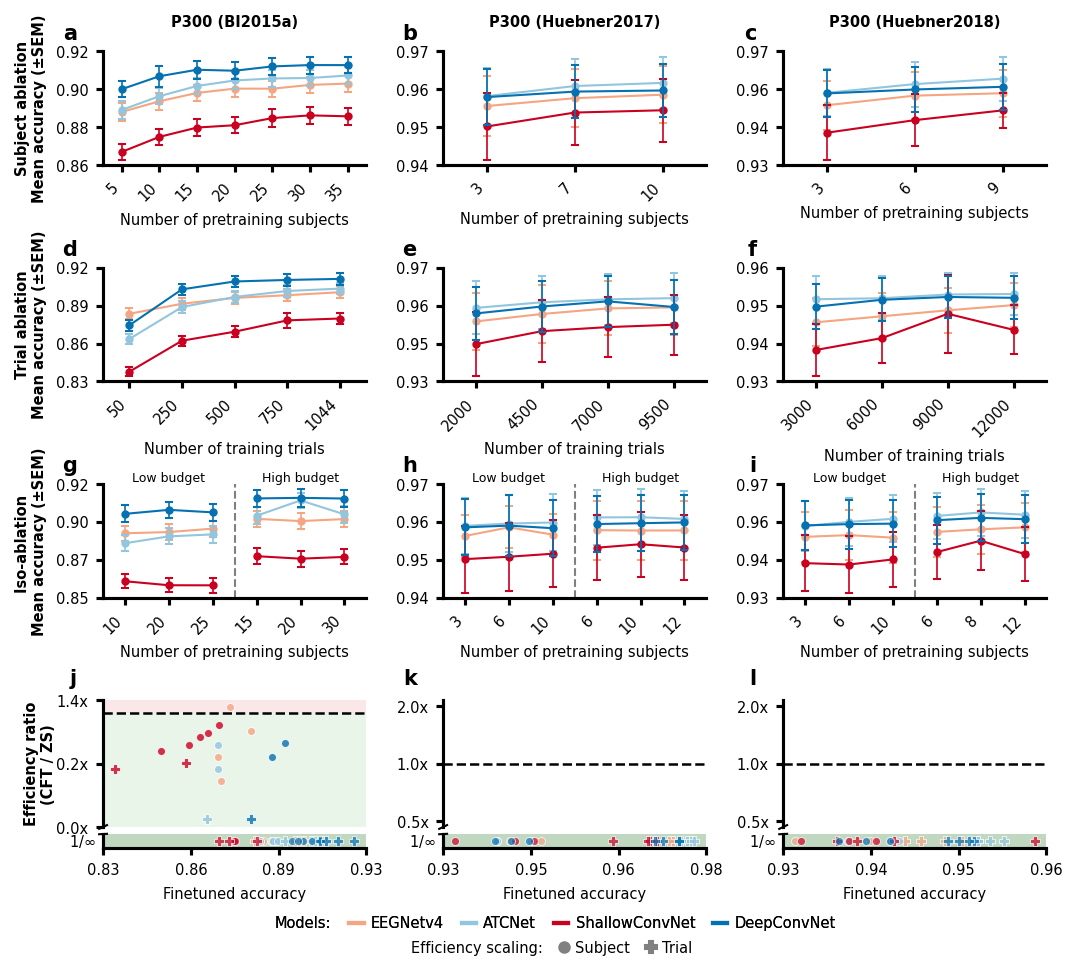


==================== Creating ZeroShot Figure for Paradigm: P300 ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 3 rows and 3 cols. Size: 7.09"W x 5.07"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_P300_ZeroShot.pdf


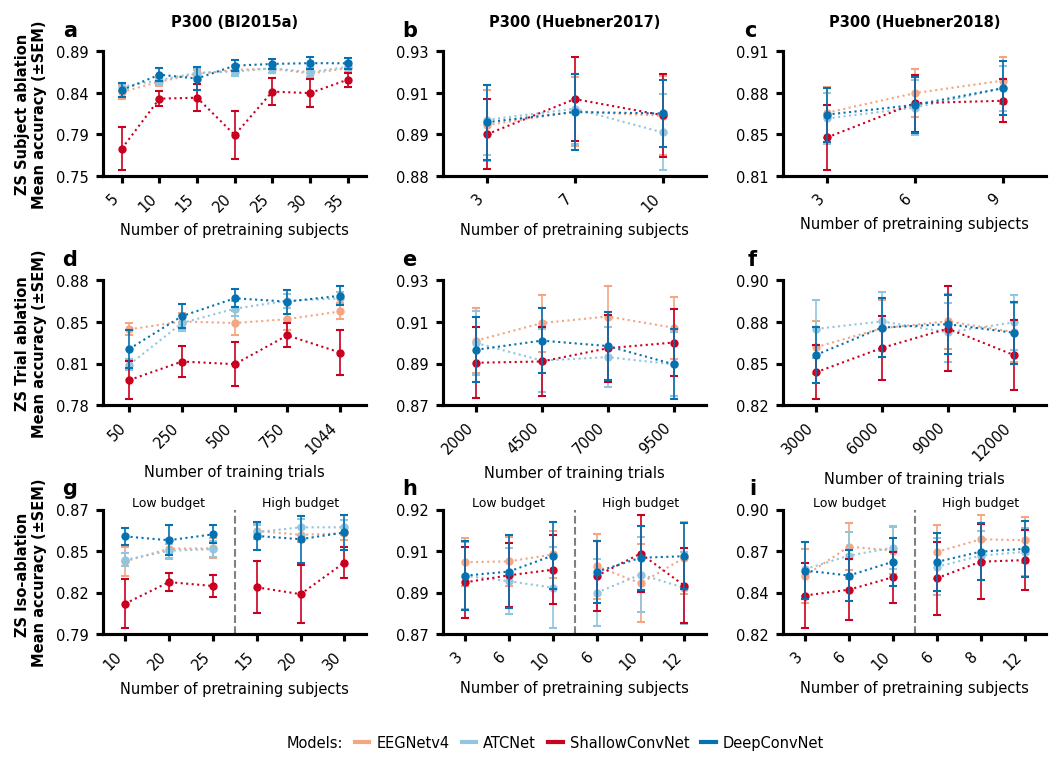


==================== Creating Finetuned_With_Efficiency Figure for Paradigm: SSVEP ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 4 rows and 3 cols. Size: 7.09"W x 6.49"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_SSVEP_Finetuned_With_Efficiency.pdf


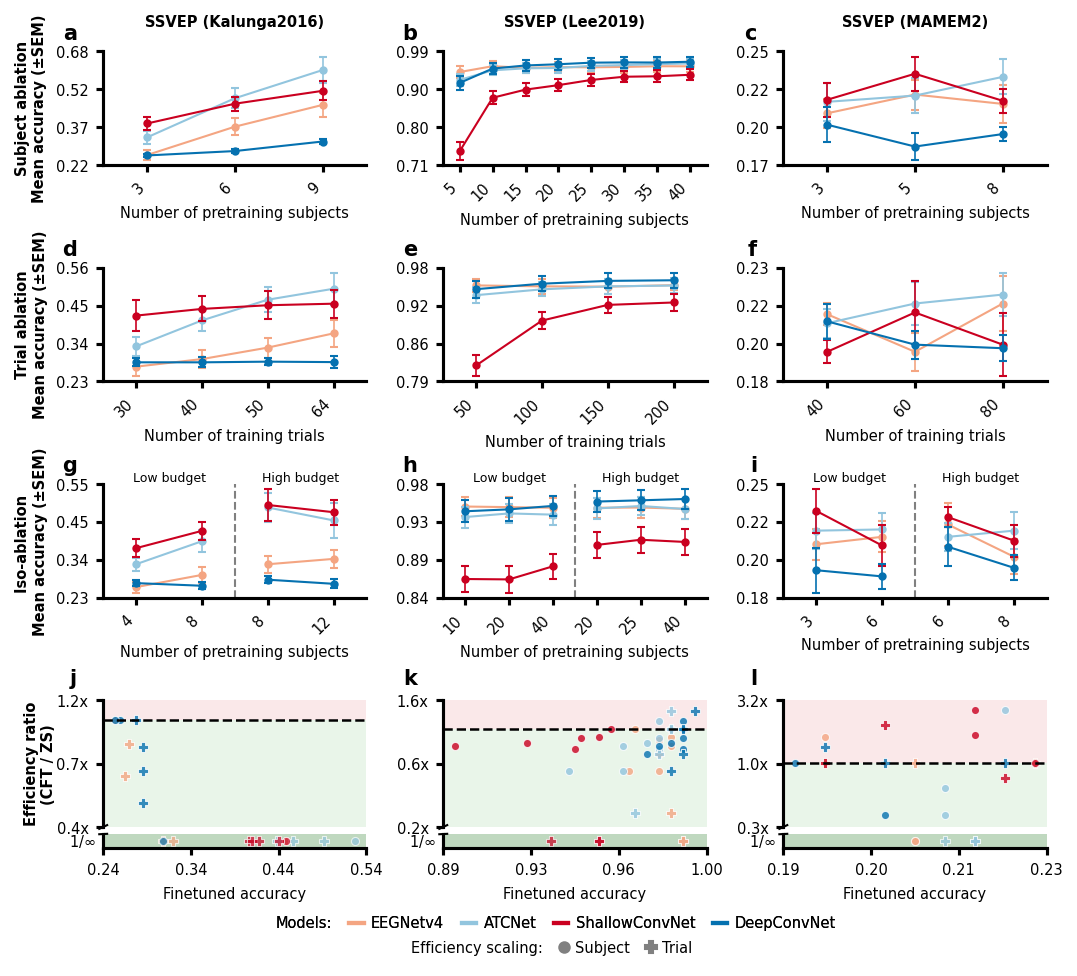


==================== Creating ZeroShot Figure for Paradigm: SSVEP ====================
Using matplotlibrc file: /mnt/lustre/work/macke/mwe626/repos/eegjepa/EDAPT_neurips/matplotlibrc
 ...creating figure with 3 rows and 3 cols. Size: 7.09"W x 5.07"H


/tmp/ipykernel_1518901/508961737.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_panel_data[accuracy_col] = pd.to_numeric(df_panel_data[accuracy_col], errors='coerce')
/tmp/ipykernel_1518901/508961737.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

 ...saving final figure to: final_figure_plots_by_paradigm/fig_ablation_SSVEP_ZeroShot.pdf


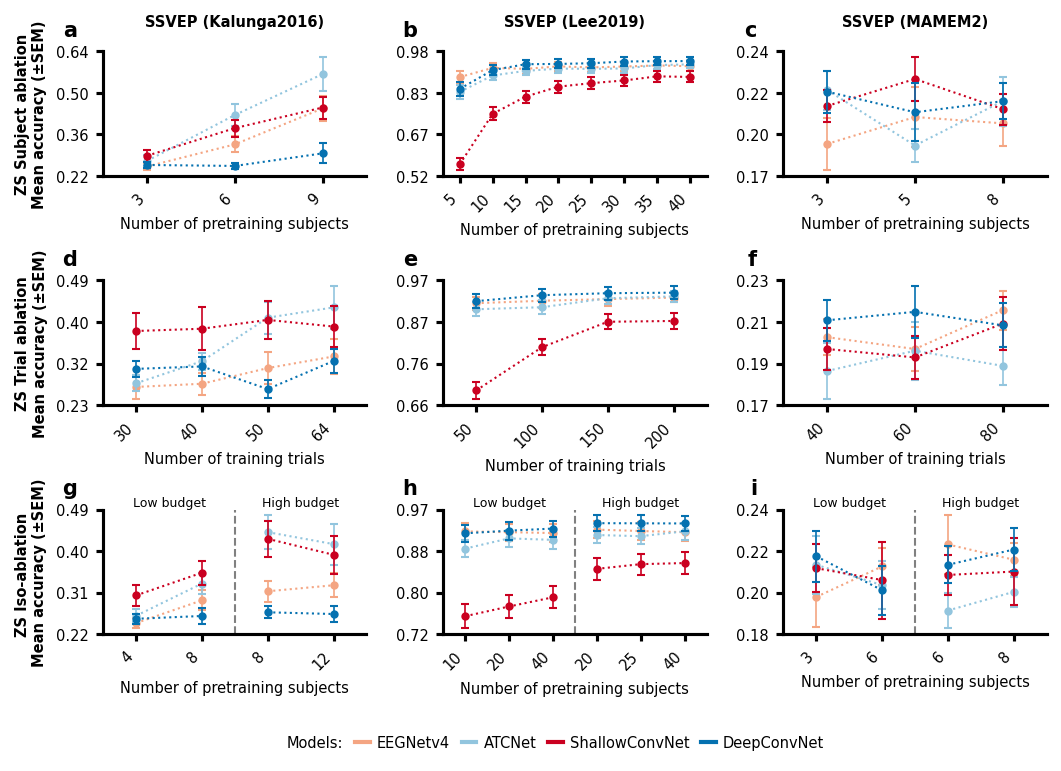


--- Plotting script finished successfully. ---


In [11]:
def create_paradigm_figure(paradigm_name: str, dataset_keys: list, df_fig3: pd.DataFrame, df_fig5: pd.DataFrame, df_fig6: pd.DataFrame, performance_type: str):
    num_cols = len(dataset_keys)
    if num_cols == 0: print(f"Skipping paradigm {paradigm_name} as it has no datasets."); return
    if performance_type == 'finetuned':
        num_rows, accuracy_col, line_style, file_suffix = 4, 'finetuned_accuracy', '-', 'Finetuned_With_Efficiency'
        y_labels = { "subject": "Subject ablation\nMean accuracy (±SEM)", "trial": "Trial ablation\nMean accuracy (±SEM)", "iso": "Iso-ablation \nMean accuracy (±SEM)", "efficiency": "Efficiency ratio\n(CFT / ZS)" }
    elif performance_type == 'zeroshot':
        num_rows, accuracy_col, line_style, file_suffix = 3, 'zero_shot_accuracy', ':', 'ZeroShot'
        y_labels = { "subject": "ZS Subject ablation\nMean accuracy (±SEM)", "trial": "ZS Trial ablation\nMean accuracy (±SEM)", "iso": "ZS Iso-ablation \nMean accuracy (±SEM)" }
    else: raise ValueError(f"Unknown performance_type: '{performance_type}'.")
    print(f"\n{'='*20} Creating {file_suffix} Figure for Paradigm: {paradigm_name.upper()} {'='*20}")
    final_figure_pdf_path = PLOTS_OUTPUT_DIR / f"fig_ablation_{paradigm_name}_{file_suffix}.pdf"
    total_w_cm = (MAX_TOTAL_WIDTH_MM / 10.0) if num_cols > 2 else (MAX_TOTAL_WIDTH_MM / 10.0) * (num_cols/3.0)
    eff_w_cm = total_w_cm - MARGIN_LEFT_CM - MARGIN_RIGHT_CM
    panel_w_cm = (eff_w_cm - (num_cols - 1) * SPACING_HORIZONTAL_CM) / num_cols if num_cols > 0 else 0
    panel_h_cm = panel_w_cm / 1.7
    total_h_cm = (num_rows * panel_h_cm) + ((num_rows - 1) * SPACING_VERTICAL_CM) + MARGIN_TOP_CM + MARGIN_BOTTOM_CM
    total_w_in, total_h_in = cm2inch(total_w_cm), cm2inch(total_h_cm)
    with get_rc_context():
        fig = plt.figure(figsize=(total_w_in, total_h_in))
        height_ratios = [1] * num_rows
        if num_rows == 4: height_ratios[3] = 1.3
        wspace_val = SPACING_HORIZONTAL_CM / panel_w_cm if panel_w_cm > 0 else 0.1
        hspace_val = (SPACING_VERTICAL_CM + 1.2) / panel_h_cm if panel_h_cm > 0 else 0.1
        gs_outer = GridSpec(num_rows, num_cols, figure=fig, hspace=hspace_val, wspace=wspace_val, height_ratios=height_ratios)
        main_axes = [[None] * num_cols for _ in range(num_rows)]
        print(f" ...creating figure with {num_rows} rows and {num_cols} cols. Size: {total_w_in:.2f}\"W x {total_h_in:.2f}\"H")
        for col_idx, dataset_key in enumerate(dataset_keys):
            is_first_col = (col_idx == 0)
            dataset_name_for_plot = DATASET_INFO.get(dataset_key, {}).get("name_for_plot", dataset_key)
            ax0 = fig.add_subplot(gs_outer[0, col_idx]); main_axes[0][col_idx] = ax0
            panel_data_r0 = df_fig3[df_fig3[DATASET_COL] == dataset_key] if not df_fig3.empty else pd.DataFrame()
            _draw_subject_ablation_on_ax(ax0, panel_data_r0, is_first_col, dataset_name_for_plot, accuracy_col, y_labels["subject"], line_style)
            ax1 = fig.add_subplot(gs_outer[1, col_idx]); main_axes[1][col_idx] = ax1
            panel_data_r1 = df_fig5[(df_fig5[DATASET_COL] == dataset_key) & (df_fig5[CONFIG_TAG_COL] == FT_CONFIG_TAG)] if not df_fig5.empty else pd.DataFrame()
            _draw_trial_ablation_on_ax(ax1, panel_data_r1, FT_CONFIG_TAG, is_first_col, accuracy_col, y_labels["trial"], line_style)
            ax2 = fig.add_subplot(gs_outer[2, col_idx]); main_axes[2][col_idx] = ax2
            panel_data_r2 = df_fig6[df_fig6[DATASET_COL] == dataset_key] if not df_fig6.empty else pd.DataFrame()
            _draw_iso_ablation_on_ax(ax2, panel_data_r2, is_first_col, dataset_key, accuracy_col, y_labels["iso"], line_style)
            if num_rows == 4:
                gs_inner = gs_outer[3, col_idx].subgridspec(2, 1, hspace=0.1, height_ratios=[0.9, 0.1])
                ax_top = fig.add_subplot(gs_inner[0]); main_axes[3][col_idx] = ax_top
                ax_bottom = fig.add_subplot(gs_inner[1], sharex=ax_top)
                _draw_efficiency_ratio_on_ax(ax_top, ax_bottom, df_fig3, df_fig5, is_first_col, dataset_key, y_labels["efficiency"])
        panel_labels = string.ascii_lowercase
        for label_idx, ax in enumerate(ax for row in main_axes for ax in row if ax):
            if label_idx < len(panel_labels):
                ax.text(-0.1, 1.25, panel_labels[label_idx], transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
        if performance_type == 'finetuned':
            models_title = mpatches.Patch(color='none', label='Models:')
            model_handles = [Line2D([0], [0], color=color, label=model, lw=2) for model, color in MODEL_COLORS.items()]
            model_leg = fig.legend(handles=[models_title] + model_handles, loc='lower center', bbox_to_anchor=(0.5, 0.035), ncol=1 + len(model_handles), frameon=False, fontsize=GLOBAL_FONTSIZE, handletextpad=0.5, columnspacing=1.2, handlelength=1)
            scaling_title = mpatches.Patch(color='none', label='Efficiency scaling:')
            symbol_handles = [Line2D([0], [0], marker='o', color='grey', label='Subject', linestyle='None', markersize=5), Line2D([0], [0], marker='P', color='grey', label='Trial', linestyle='None', markersize=6)]
            fig.legend(handles=[scaling_title] + symbol_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=1 + len(symbol_handles), frameon=False, fontsize=GLOBAL_FONTSIZE, handletextpad=0.5, columnspacing=1.2, handlelength=0.5)
            fig.add_artist(model_leg)
        else:
             model_legend_elements = [Line2D([0], [0], color=color, label=model_name, linestyle='-', linewidth=2) for model_name, color in MODEL_COLORS.items()]
             fig.legend(handles=[mpatches.Patch(color='none', label='Models:')] + model_legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.001), ncol=5, frameon=False, fontsize=GLOBAL_FONTSIZE, handletextpad=0.5, columnspacing=0.8, handlelength=1.0)
        left_norm, right_norm = MARGIN_LEFT_CM / total_w_cm, 1 - (MARGIN_RIGHT_CM / total_w_cm)
        bottom_norm, top_norm = MARGIN_BOTTOM_CM / total_h_cm, 1 - (MARGIN_TOP_CM / total_h_cm)
        fig.subplots_adjust(left=left_norm, right=right_norm, bottom=bottom_norm, top=top_norm)
        print(f" ...saving final figure to: {final_figure_pdf_path}")
        fig.savefig(final_figure_pdf_path, dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

# --- Main Execution Block ---
if __name__ == "__main__":
    # Define the directory where the prepared data was saved
    DATA_DIR = Path("./prepared_data")
    PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print("--- Starting Plotting Script ---")
    
    # --- Load the complete, prepared datasets from CSV files ---
    print("\n1. Loading prepared data from CSVs...")
    try:
        df_fig3 = pd.read_csv(DATA_DIR / "fig3_subject_ablation_complete.csv")
        print(f"   Loaded {len(df_fig3)} rows for subject ablation.")
    except FileNotFoundError:
        df_fig3 = pd.DataFrame()
        print("    Subject ablation file not found. Plots will be empty.")

    try:
        df_fig5 = pd.read_csv(DATA_DIR / "fig5_trial_ablation_complete.csv")
        print(f"   Loaded {len(df_fig5)} rows for trial ablation.")
    except FileNotFoundError:
        df_fig5 = pd.DataFrame()
        print("    Trial ablation file not found. Plots will be empty.")

    try:
        df_fig6 = pd.read_csv(DATA_DIR / "fig6_iso_ablation_complete.csv")
        print(f"   Loaded {len(df_fig6)} rows for iso ablation.")
    except FileNotFoundError:
        df_fig6 = pd.DataFrame()
        print("    Iso ablation file not found. Plots will be empty.")

    # --- Run a basic check on the loaded data ---
    report_missing_configurations(df_fig3, df_fig5, df_fig6)

    # --- Group datasets by paradigm ---
    paradigms = defaultdict(list)
    for key, info in DATASET_INFO.items():
        paradigms[info['paradigm']].append(key)

    # --- Generate a figure for each paradigm ---
    for paradigm_name, dataset_keys in paradigms.items():
        sorted_keys = sorted(dataset_keys)
        # 1. Generate the finetuned performance plots (with efficiency row)
        create_paradigm_figure(paradigm_name, sorted_keys, df_fig3, df_fig5, df_fig6, 'finetuned')
        # 2. Generate the zero-shot performance plots
        create_paradigm_figure(paradigm_name, sorted_keys, df_fig3, df_fig5, df_fig6, 'zeroshot')

    print("\n--- Plotting script finished successfully. ---")
